# вариант 1

Прогноз для коэффициента загрузки гостиниц методом экспоненциального сглаживания.

Здесь рассматривается столбец `x1` из файла `data.csv`.
Это загрузка гостиниц в районе chicago central business district.

Нужно восстановить 8 последних месяцев 2003 года, где в таблице стоят пропуски.


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format


## идея метода

Если сказать совсем просто, метод экспоненциального сглаживания делает две вещи:
- сильнее доверяет свежим наблюдениям;
- слабее доверяет очень старым наблюдениям.

Для этой задачи берём модель Хольта-Винтерса, потому что в ряде есть:
- уровень, то есть обычный общий уровень ряда;
- тренд, то есть медленное изменение во времени;
- сезонность, то есть повторение похожей картины по месяцам.

Так как данные месячные, длина сезона равна `12`.


In [2]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12,
}

month_names_ru = {
    1: 'январь',
    2: 'февраль',
    3: 'март',
    4: 'апрель',
    5: 'май',
    6: 'июнь',
    7: 'июль',
    8: 'август',
    9: 'сентябрь',
    10: 'октябрь',
    11: 'ноябрь',
    12: 'декабрь',
}

data = pd.read_csv('data.csv', sep=';', dtype=str)

data['month'] = data['date1'].map(month_map)
data['date'] = pd.to_datetime(
    dict(year=data['date2'].astype(int), month=data['month'], day=1)
)

data['x1'] = pd.to_numeric(
    data['x1'].str.replace(',', '.', regex=False),
    errors='coerce'
)

series = data.set_index('date')['x1']
train = series.dropna().copy()
future_dates = series[series.isna()].index

print(f'известных значений: {len(train)}')
print(f'месяцев для прогноза: {len(future_dates)}')

display(data[['date', 'x1']].head())
display(data[['date', 'x1']].tail(12))


известных значений: 112
месяцев для прогноза: 8


,date,x1
0,1994-01-01,44.30
1,1994-02-01,54.70
2,1994-03-01,61.90
3,1994-04-01,69.10
4,1994-05-01,70.80


,date,x1
108,2003-01-01,51.60
109,2003-02-01,52.70
110,2003-03-01,65.00
111,2003-04-01,69.00
112,2003-05-01,NaN
113,2003-06-01,NaN
114,2003-07-01,NaN
115,2003-08-01,NaN
116,2003-09-01,NaN
117,2003-10-01,NaN


## исходный ряд

Сначала просто посмотрим на данные.
Так легче увидеть, что значения по месяцам заметно меняются и что в конце ряда действительно не хватает 8 месяцев.


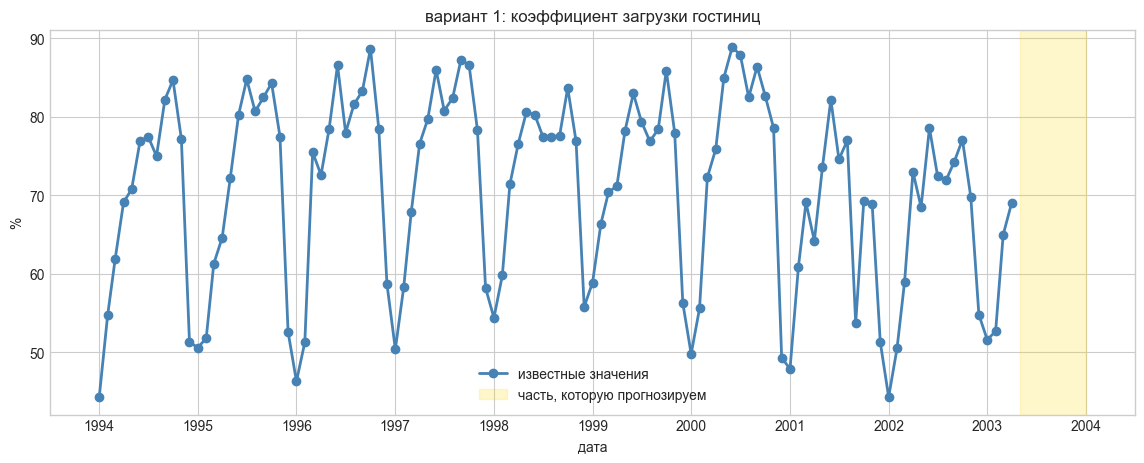

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, color='steelblue', label='известные значения')

if len(future_dates) > 0:
    plt.axvspan(
        future_dates[0],
        future_dates[-1] + pd.offsets.MonthEnd(1),
        color='gold',
        alpha=0.2,
        label='часть, которую прогнозируем'
    )

plt.title('вариант 1: коэффициент загрузки гостиниц')
plt.xlabel('дата')
plt.ylabel('%')
plt.legend()
plt.show()


## строим модель

Используем модель Хольта-Винтерса.

Почему параметры выбраны именно так:
- `trend='add'` означает, что тренд меняется как прибавка;
- `seasonal='mul'` означает, что сезонность работает как коэффициент;
- `seasonal_periods=12` означает повторение рисунка раз в 12 месяцев.

Для процентов загрузки такой вариант выглядит естественно: сезонность здесь удобнее понимать не как фиксированную добавку, а как относительное усиление или ослабление уровня ряда.


In [4]:
train_for_model = train.copy()
train_for_model.index = pd.DatetimeIndex(train_for_model.index, freq='MS')

model = ExponentialSmoothing(
    train_for_model,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
)

fit = model.fit(optimized=True, use_brute=True)

alpha = fit.params['smoothing_level']
beta = fit.params['smoothing_trend']
gamma = fit.params['smoothing_seasonal']

params_table = pd.DataFrame({
    'параметр': ['alpha', 'beta', 'gamma'],
    'что означает': [
        'насколько быстро обновляется уровень ряда',
        'насколько быстро обновляется тренд',
        'насколько быстро обновляется сезонность'
    ],
    'значение': [alpha, beta, gamma]
})

display(params_table)


,параметр,что означает,значение
0,alpha,насколько быстро обновляется уровень ряда,0.37
1,beta,насколько быстро обновляется тренд,0.00
2,gamma,насколько быстро обновляется сезонность,0.00


## проверяем, как модель описывает известную часть ряда

Здесь полезно сравнить реальные значения и линию модели на уже известных данных.
Если линии идут похоже, значит модель достаточно разумно уловила поведение ряда.


средняя абсолютная ошибка: 2.86
корень из средней квадратичной ошибки: 4.08


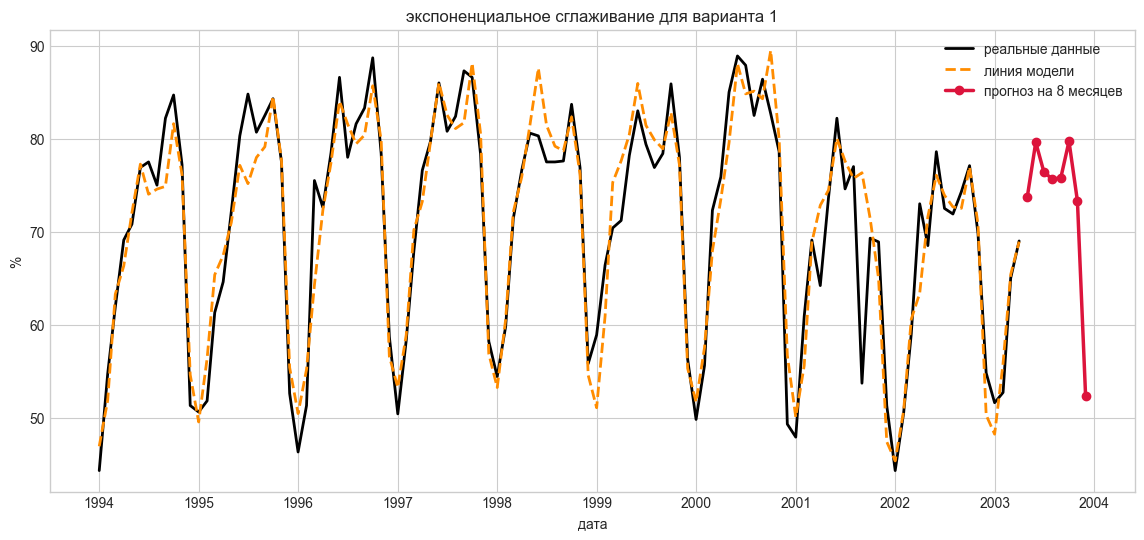

In [5]:
fitted = pd.Series(fit.fittedvalues.values, index=train.index)
forecast = fit.forecast(len(future_dates))
forecast.index = future_dates

mae = np.mean(np.abs(train - fitted))
rmse = np.sqrt(np.mean((train - fitted) ** 2))

print(f'средняя абсолютная ошибка: {mae:.2f}')
print(f'корень из средней квадратичной ошибки: {rmse:.2f}')

plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, linewidth=2, color='black', label='реальные данные')
plt.plot(fitted.index, fitted.values, linewidth=2, linestyle='--', color='darkorange', label='линия модели')
plt.plot(forecast.index, forecast.values, linewidth=2.5, marker='o', color='crimson', label='прогноз на 8 месяцев')
plt.title('экспоненциальное сглаживание для варианта 1')
plt.xlabel('дата')
plt.ylabel('%')
plt.legend()
plt.show()


## таблица прогноза

Ниже показаны те 8 месяцев, которые модель восстановила вместо пропусков.


,дата,"прогноз загрузки, %"
0,май 2003,73.75
1,июнь 2003,79.61
2,июль 2003,76.41
3,август 2003,75.65
4,сентябрь 2003,75.79
5,октябрь 2003,79.72
6,ноябрь 2003,73.30
7,декабрь 2003,52.31


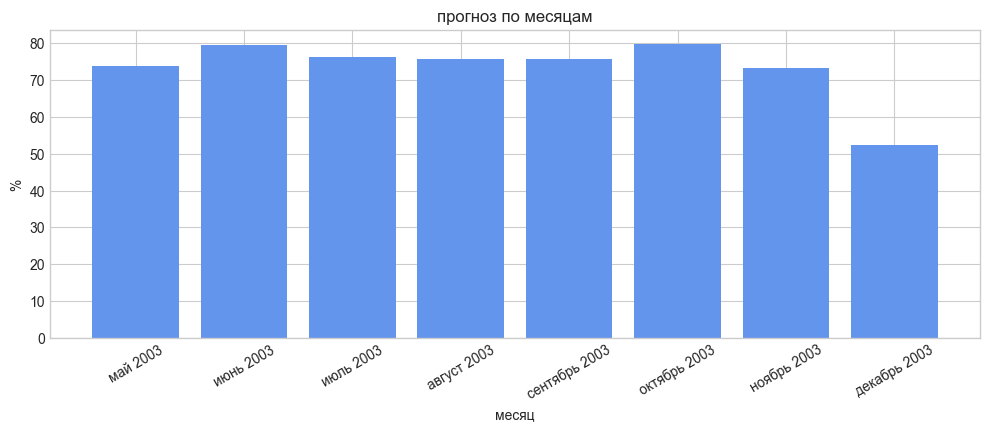

In [6]:
forecast_table = pd.DataFrame({
    'дата': [f"{month_names_ru[d.month]} {d.year}" for d in future_dates],
    'прогноз загрузки, %': np.round(forecast.values, 2)
})

display(forecast_table)

plt.figure(figsize=(12, 4))
plt.bar(forecast_table['дата'], forecast_table['прогноз загрузки, %'], color='cornflowerblue')
plt.title('прогноз по месяцам')
plt.xlabel('месяц')
plt.ylabel('%')
plt.xticks(rotation=30)
plt.show()


## заполняем пропуски в исходной таблице

Чтобы итог был наглядным, подставим прогноз в пустые места и посмотрим на конец ряда целиком.


In [7]:
result = data[['date', 'x1']].copy()
result['итоговое значение'] = result['x1']
result.loc[result['итоговое значение'].isna(), 'итоговое значение'] = forecast.values
result['месяц'] = result['date'].apply(lambda d: f"{month_names_ru[d.month]} {d.year}")

final_table = result[['месяц', 'итоговое значение']].tail(12).reset_index(drop=True)
display(final_table)


,месяц,итоговое значение
0,январь 2003,51.60
1,февраль 2003,52.70
2,март 2003,65.00
3,апрель 2003,69.00
4,май 2003,73.75
5,июнь 2003,79.61
6,июль 2003,76.41
7,август 2003,75.65
8,сентябрь 2003,75.79
9,октябрь 2003,79.72


## вывод

Для варианта 1 построен прогноз методом экспоненциального сглаживания Хольта-Винтерса.
Модель использует уровень, тренд и сезонность, поэтому подходит для месячного ряда с повторяющимся рисунком по месяцам.

В результате получены прогнозные значения для периода с мая по декабрь 2003 года.
